<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape     : (99901, 45)
y shape     : (99901,)
n_features  : 45
Train samples : 79,911
Test  samples : 19,962
Class weights (Down/Flat/Up): [1.48  0.603 1.499]
Model           : Bidirectional LSTM
Input features  : 45
Trainable params: 15,107

  Training Bidirectional LSTM
Ep   1/40 | Train Loss 1.2207 | Val Loss 1.0689 | Val Acc 0.3371
Ep   2/40 | Train Loss 1.0973 | Val Loss 1.0534 | Val Acc 0.3522
Ep   3/40 | Train Loss 1.0833 | Val Loss 1.0459 | Val Acc 0.3614
Ep   4/40 | Train Loss 1.0714 | Val Loss 1.0388 | Val Acc 0.3571
Ep   5/40 | Train Loss 1.0634 | Val Loss 1.0311 | Val Acc 0.3639
Ep   6/40 | Train Loss 1.0562 | Val Loss 1.0269 | Val Acc 0.3768
Ep   7/40 | Train Loss 1.0509 | Val Loss 1.0224 | Val Acc 0.3828
Ep   8/40 | Train Loss 1.0451 | Val Loss 1.0195 | Val Acc 0.3828
Ep   9/40 | Train Loss 1.0419 | Val Loss 1.0176 | Val Acc 0.385

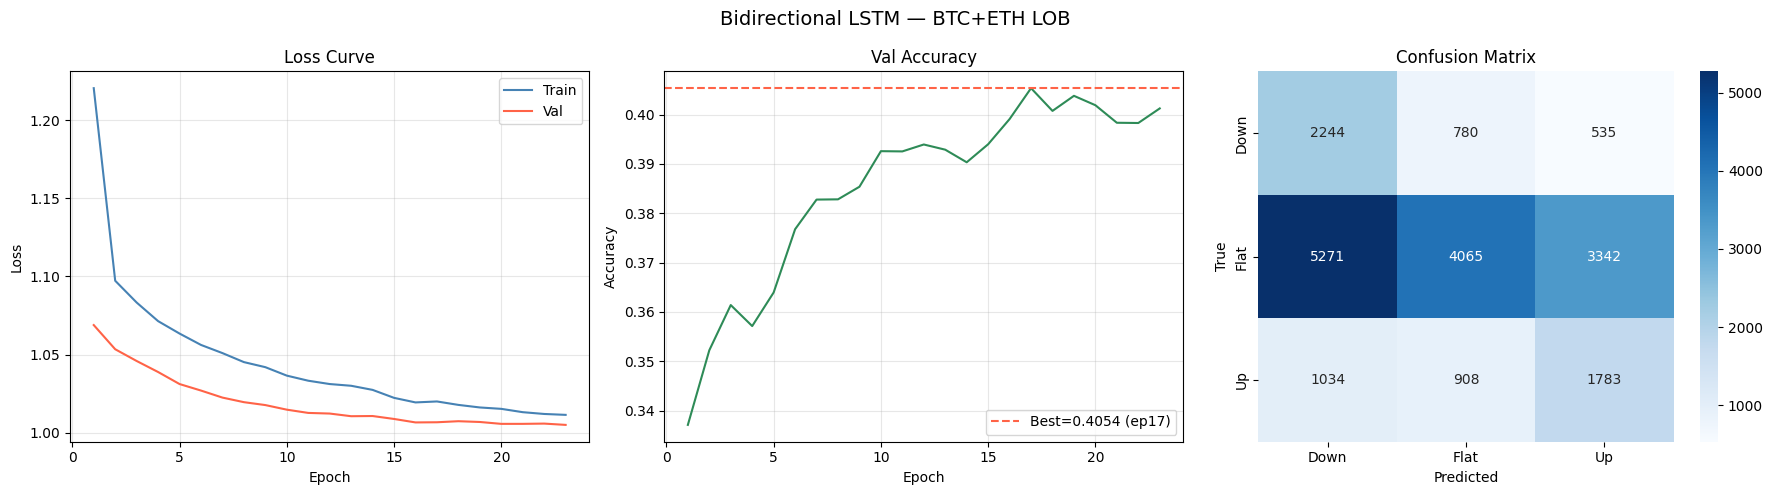

In [3]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Hyperparameters
# ==========================================
SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 16
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 40
LR          = 1e-4
PATIENCE    = 6

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ==========================================
# 2. Load Processed Data
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

save_df = pd.read_csv("/content/drive/MyDrive/lob_full.csv")

split_idx = int((save_df['split'] == 'train').sum())

X_all = save_df.drop(columns=['label', 'split', 'future_return']).values.astype(np.float32)
y_all = (save_df['label'].values + 1).astype(np.int64)

returns_all = save_df['future_return'].values

print(f"X shape     : {X_all.shape}")
print(f"y shape     : {y_all.shape}")
print(f"n_features  : {X_all.shape[1]}")

# ==========================================
# 3. Dataset & DataLoaders
# ==========================================
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]

def build_loaders(X, y, split):
    embargo_gap = 10

    X_tr   = X[:split]
    X_te   = X[split + embargo_gap :]
    y_tr, y_te = y[:split], y[split + embargo_gap :]

    y_tr_targets = y_tr[SEQ_LEN - 1:]
    counts  = np.bincount(y_tr_targets, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}")
    print(f"Test  samples : {len(test_loader.dataset):,}")
    print(f"Class weights (Down/Flat/Up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w

train_loader, test_loader, class_w = build_loaders(X_all, y_all, split_idx)

# ==========================================
# 4. Model Architecture
# ==========================================
class LOBLSTM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        # MODIFIED: Removed input_proj bottleneck. Directly feed n_features to LSTM.
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = N_LAYERS,
            batch_first   = True,
            bidirectional = True,
            dropout       = DROPOUT if N_LAYERS > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(HIDDEN_SIZE*2)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE*2, HIDDEN_SIZE),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        # MODIFIED: x shape directly goes to LSTM (B, T, n_features)
        _, (h_n, _) = self.lstm(x)

        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat((h_forward, h_backward), dim=1)
        # h = h_n[-1]
        h = self.norm(h)
        return self.head(h)

n_features = X_all.shape[1]
model      = LOBLSTM(n_features).to(DEVICE)
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model           : Bidirectional LSTM")
print(f"Input features  : {n_features}")
print(f"Trainable params: {n_params:,}")

# ==========================================
# 5. Training Loop
# ==========================================

criterion = nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc, best_state, patience_cnt = 0.0, None, 0

print("\n" + "=" * 60)
print("  Training Bidirectional LSTM")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(yb)
    scheduler.step()
    train_loss = running / len(train_loader.dataset)

    model.eval()
    vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            vloss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)

    val_loss = vloss / total
    val_acc  = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Ep {epoch:3d}/{EPOCHS} | Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc, patience_cnt = val_acc, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
            break

model.load_state_dict(best_state)
print(f"\nBest Val Accuracy: {best_acc:.4f}")

# ==========================================
# 6. Evaluation
# ==========================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))

        # MODIFIED: Removed threshold logic entirely to evaluate raw predictions
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

print("\n" + "=" * 60)
print("  Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

# ==========================================
# 7. Plots
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Bidirectional LSTM — BTC+ETH LOB", fontsize=14)

ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

best_ep = int(np.argmax(history["val_acc"])) + 1
axes[1].plot(ep, history["val_acc"], color="seagreen")
axes[1].axhline(best_acc, color="tomato", linestyle="--", label=f"Best={best_acc:.4f} (ep{best_ep})")
axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Down","Flat","Up"],
            yticklabels=["Down","Flat","Up"])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()



信号长度: 19962
收益率长度: 19962

🔍 RUNNING THRESHOLD SWEEP (Fee: 1.5 bps)
🏆 最优开仓阈值发现: 0.450
   -> 夏普比率: 682.82
   -> 净收益率: 57.40%
   -> 总换手次数: 2,674 次



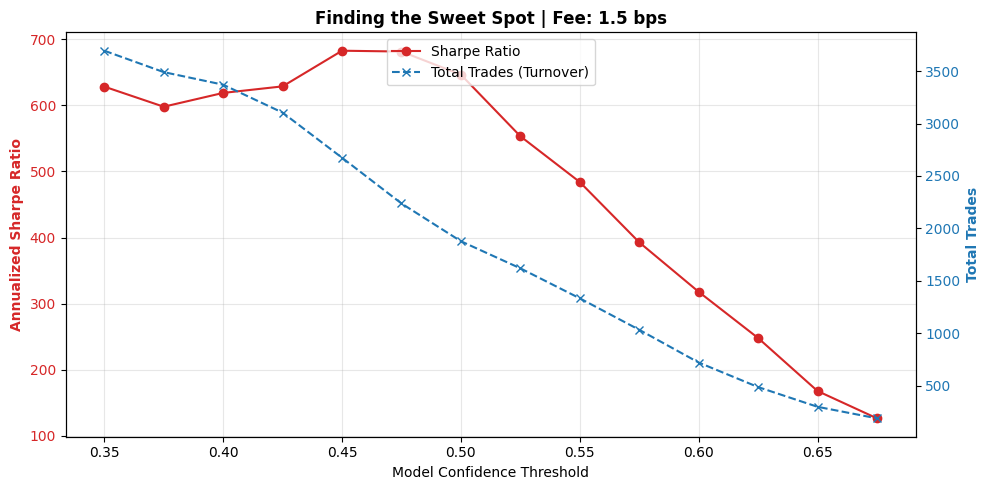

In [7]:
# ==========================================
# 8. Threshold Sweeping & Backtesting
# ==========================================
def sweep_thresholds(model, test_loader, future_returns, fee=0.00015):
    print("\n" + "=" * 60)
    print(f"🔍 RUNNING THRESHOLD SWEEP (Fee: {fee*10000:.1f} bps)")
    print("=" * 60)

    model.eval()
    all_probs = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            logits = model(Xb.to(DEVICE))
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    probs_array = np.concatenate(all_probs)

    thresholds = np.arange(0.35, 0.675, 0.025)
    results = []

    for th in thresholds:
        preds = np.ones(len(probs_array), dtype=np.int64)
        preds[probs_array[:, 0] > th] = 0
        preds[probs_array[:, 2] > th] = 2

        signals = preds - 1
        trades = np.abs(np.diff(signals, prepend=0))

        net_returns = (signals * future_returns) - (trades * fee)
        cum_returns = np.cumprod(1 + net_returns)

        total_ret = cum_returns[-1] - 1
        annual_factor = 365 * 24 * 3600
        sharpe = np.mean(net_returns) / (np.std(net_returns) + 1e-8) * np.sqrt(annual_factor)

        results.append({
            "Threshold": th,
            "Total Return": total_ret,
            "Sharpe Ratio": sharpe,
            "Total Trades": trades.sum()
        })

    df_results = pd.DataFrame(results)

    best_idx = df_results['Sharpe Ratio'].idxmax()
    best_row = df_results.loc[best_idx]

    print(f"🏆 最优开仓阈值发现: {best_row['Threshold']:.3f}")
    print(f"   -> 夏普比率: {best_row['Sharpe Ratio']:.2f}")
    print(f"   -> 净收益率: {best_row['Total Return']:.2%}")
    print(f"   -> 总换手次数: {best_row['Total Trades']:,.0f} 次\n")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = 'tab:red'
    ax1.set_xlabel('Model Confidence Threshold')
    ax1.set_ylabel('Annualized Sharpe Ratio', color=color1, fontweight='bold')
    line1 = ax1.plot(df_results['Threshold'], df_results['Sharpe Ratio'], color=color1, marker='o', label='Sharpe Ratio')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    color2 = 'tab:blue'
    ax2.set_ylabel('Total Trades', color=color2, fontweight='bold')
    line2 = ax2.plot(df_results['Threshold'], df_results['Total Trades'], color=color2, marker='x', linestyle='--', label='Total Trades (Turnover)')
    ax2.tick_params(axis='y', labelcolor=color2)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center')

    plt.title(f"Finding the Sweet Spot | Fee: {fee*10000:.1f} bps", fontweight='bold')
    fig.tight_layout()
    plt.show()

    return df_results, best_row['Threshold']

# ---------------------------------------------------------
# 立即执行：提取严格对齐的测试集收益率并开始扫描
# ---------------------------------------------------------

# ---------------------------------------------------------
# 立即执行：提取严格对齐的测试集收益率并开始扫描
# ---------------------------------------------------------
# 1. 直接获取当前测试集的真实样本数
current_test_len = len(test_loader.dataset)

# 2. 从 returns_all 的最末尾向前取相同数量的样本
# 这是最稳妥的方法，因为 test_loader 总是包含数据集最后面的连续样本
test_returns_aligned = returns_all[-current_test_len:]

# 3. 再次检查，这次必须成功
print(f"信号长度: {current_test_len}")
print(f"收益率长度: {len(test_returns_aligned)}")

assert len(test_returns_aligned) == current_test_len, f"对齐失败！需要 {current_test_len} 但只有 {len(test_returns_aligned)}"

# 运行扫描器！
df_sweep, optimal_th = sweep_thresholds(model, test_loader, test_returns_aligned, fee=0.00015)


  Classification Report
              precision    recall  f1-score   support

        Down       0.26      0.63      0.37      3559
        Flat       0.71      0.32      0.44     12678
          Up       0.32      0.48      0.38      3725

    accuracy                           0.41     19962
   macro avg       0.43      0.48      0.40     19962
weighted avg       0.55      0.41      0.42     19962

📊 量化回测报告 (手续费: 0.015%)
总净收益率 (Total Return) : 47.03%
年化夏普比率 (Sharpe Ratio) : 536.41
最大回撤 (Max Drawdown)   : 3.65%
交易胜率 (Win Rate)       : 46.14%
总交易调仓次数            : 2,778


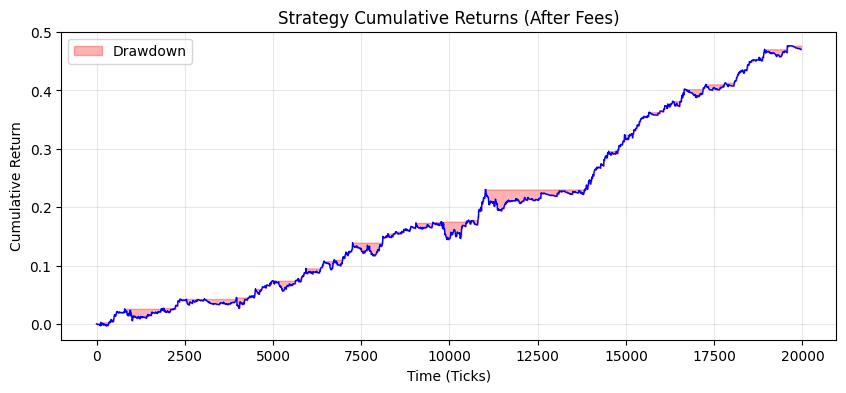

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_vectorized_backtest(y_pred_labels, future_returns, fee_rate=0.0005):
    """
    标准的向量化回测引擎
    :param y_pred_labels: 模型的预测结果数组 (0, 1, 2)
    :param future_returns: 真实的未来收益率数组 (例如 0.0015)
    :param fee_rate: 单边交易手续费率 (默认 0.05% 即万分之五)
    """

    # 1. 标签转信号 (0,1,2 -> -1,0,1)
    signals = y_pred_labels - 1

    # 2. 原始收益 = 信号 * 未来真实收益
    # 注意：这里的未来收益是指你预测的那个时间窗口的收益
    gross_returns = signals * future_returns

    # 3. 计算交易成本
    # np.diff 计算前后时刻的信号差值，如果差值不为0，说明进行了交易
    # 例如从 1 变成 -1，差值的绝对值是 2（平多开空，算两次手续费）
    signal_changes = np.abs(np.diff(signals, prepend=0))
    transaction_costs = signal_changes * fee_rate

    # 4. 计算净收益与累计收益
    net_returns = gross_returns - transaction_costs
    cum_returns = np.cumsum(net_returns) # 资金曲线

    # 5. 计算量化核心指标
    total_return = cum_returns[-1]

    # 高频数据的夏普比率年化调整 (假设一天交易 24 小时，一秒一次)
    # 夏普 = 均值 / 标准差 * sqrt(每年交易次数)
    annual_factor = np.sqrt(3600 * 24 * 365)
    if np.std(net_returns) == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = (np.mean(net_returns) / np.std(net_returns)) * annual_factor

    # 计算最大回撤
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = running_max - cum_returns
    max_drawdown = drawdown.max()

    # 胜率 (赚钱的次数 / 总交易次数)
    trades_mask = signals != 0
    win_rate = (net_returns > 0).sum() / (trades_mask.sum() + 1e-8)

    # 打印回测报告
    print("=" * 40)
    print(f"📊 量化回测报告 (手续费: {fee_rate*100:.3f}%)")
    print("=" * 40)
    print(f"总净收益率 (Total Return) : {total_return:.2%}")
    print(f"年化夏普比率 (Sharpe Ratio) : {sharpe_ratio:.2f}")
    print(f"最大回撤 (Max Drawdown)   : {max_drawdown:.2%}")
    print(f"交易胜率 (Win Rate)       : {win_rate:.2%}")
    print(f"总交易调仓次数            : {np.sum(signal_changes != 0):,}")

    # 6. 画出资金曲线
    plt.figure(figsize=(10, 4))
    plt.plot(cum_returns, color='blue', linewidth=1)
    plt.title("Strategy Cumulative Returns (After Fees)")
    plt.xlabel("Time (Ticks)")
    plt.ylabel("Cumulative Return")
    plt.grid(True, alpha=0.3)
    plt.fill_between(range(len(drawdown)), running_max, cum_returns, color='red', alpha=0.3, label='Drawdown')
    plt.legend()
    plt.show()

    return cum_returns

print("\n" + "=" * 60)
print("  Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

# ==========================================
# 新增：运行量化回测 (RQ4)
# ==========================================
# 1. 重新计算 embargo_gap (和你 build_loaders 里保持一致)
embargo_gap = 10

# 2. 精确对齐真实收益率！
# 因为测试集是从 split_idx + embargo_gap 开始的
# 且 LOBDataset 因为滑动窗口吃掉了前 (SEQ_LEN - 1) 个数据
start_idx = split_idx + embargo_gap + SEQ_LEN - 1
test_future_returns = returns_all[start_idx : start_idx + len(y_pred)]

# 3. 检查长度是否绝对一致 (防错机制)
assert len(y_pred) == len(test_future_returns), f"长度不匹配! y_pred:{len(y_pred)}, returns:{len(test_future_returns)}"

# 4. Call 回测函数！(假设币安等交易所万分之五的手续费)
cum_returns = run_vectorized_backtest(y_pred, test_future_returns, fee_rate=0.00015)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

🚀 RUNNING EXPERIMENT: Exp 1: Full (PCA LOB + Market)
Features    : 45
Early stop at epoch 15. Best val acc: 0.4775

  Classification Report
              precision    recall  f1-score   support

        Down       0.28      0.50      0.36      3559
        Flat       0.71      0.49      0.58     12678
          Up       0.32      0.41      0.36      3725

    accuracy                           0.48     19962
   macro avg       0.44      0.47      0.43     19962
weighted avg       0.56      0.48      0.50     19962


---------------------------------------------
📊 BACKTEST RESULTS: Exp 1: Full (PCA LOB + Market) (Fee: 1.5 bps)
---------------------------------------------
Total Net Return : 44.09%
Annualized Sharpe: 437.44
Max Drawdown     : -4.04%
Win Rate         : 47.08%
Total Turnover   : 2,856 (Position Changes)


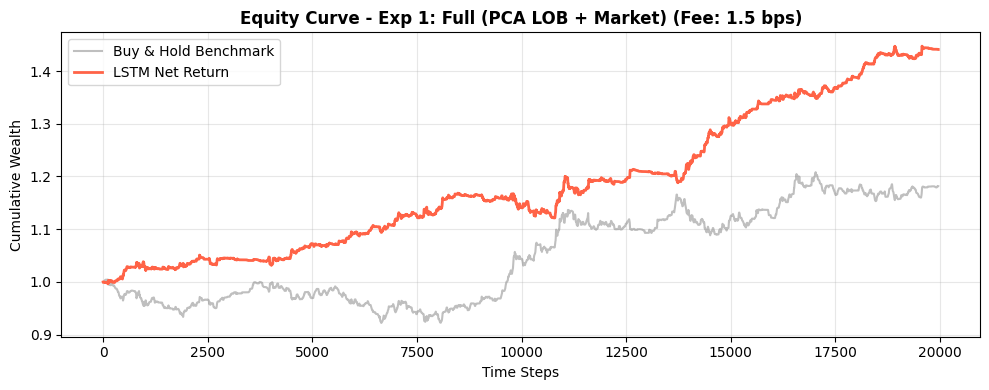

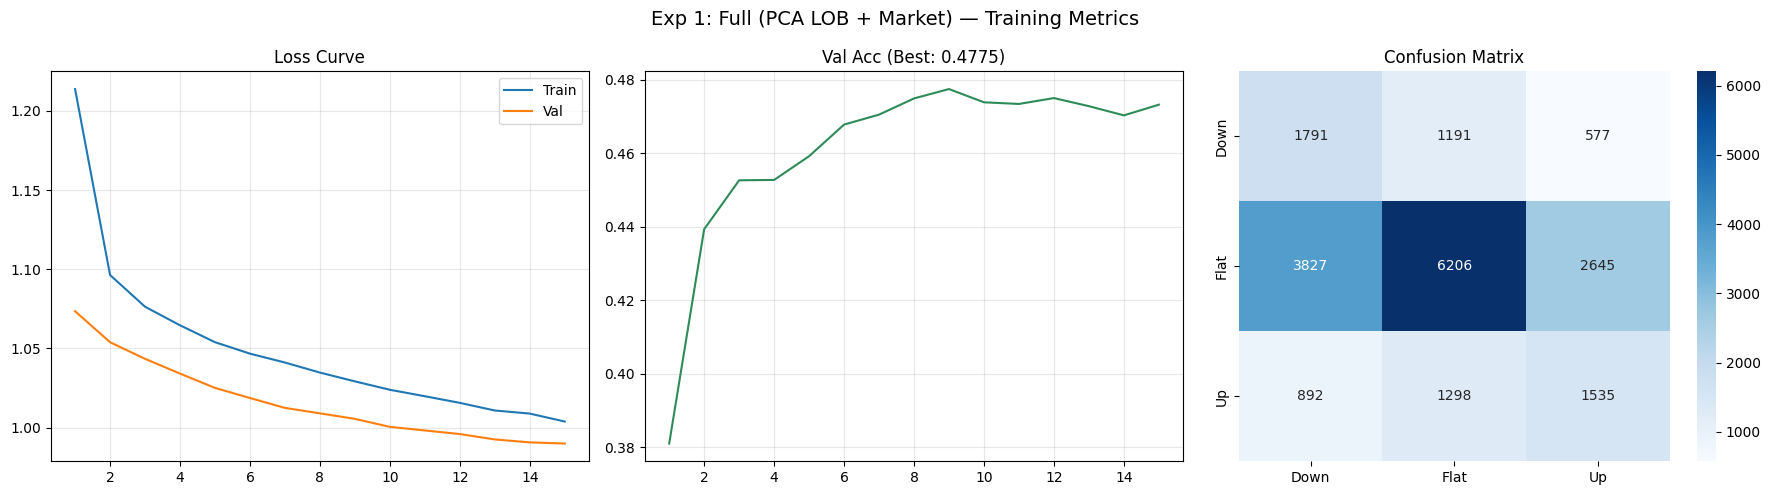


🚀 RUNNING EXPERIMENT: Exp 2: No PCA (Raw LOB + Market)
Features    : 75
Early stop at epoch 29. Best val acc: 0.4940

  Classification Report
              precision    recall  f1-score   support

        Down       0.29      0.50      0.37      3559
        Flat       0.73      0.48      0.58     12678
          Up       0.35      0.52      0.42      3725

    accuracy                           0.49     19962
   macro avg       0.46      0.50      0.46     19962
weighted avg       0.58      0.49      0.51     19962


---------------------------------------------
📊 BACKTEST RESULTS: Exp 2: No PCA (Raw LOB + Market) (Fee: 1.5 bps)
---------------------------------------------
Total Net Return : 56.53%
Annualized Sharpe: 527.49
Max Drawdown     : -2.78%
Win Rate         : 47.77%
Total Turnover   : 3,518 (Position Changes)


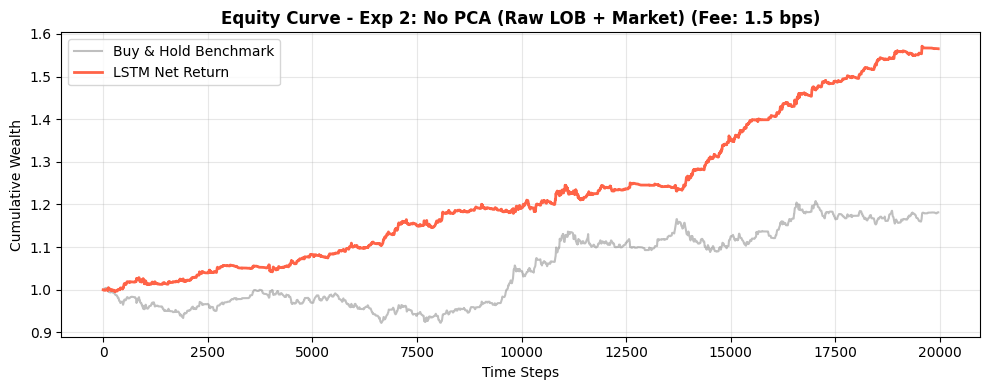

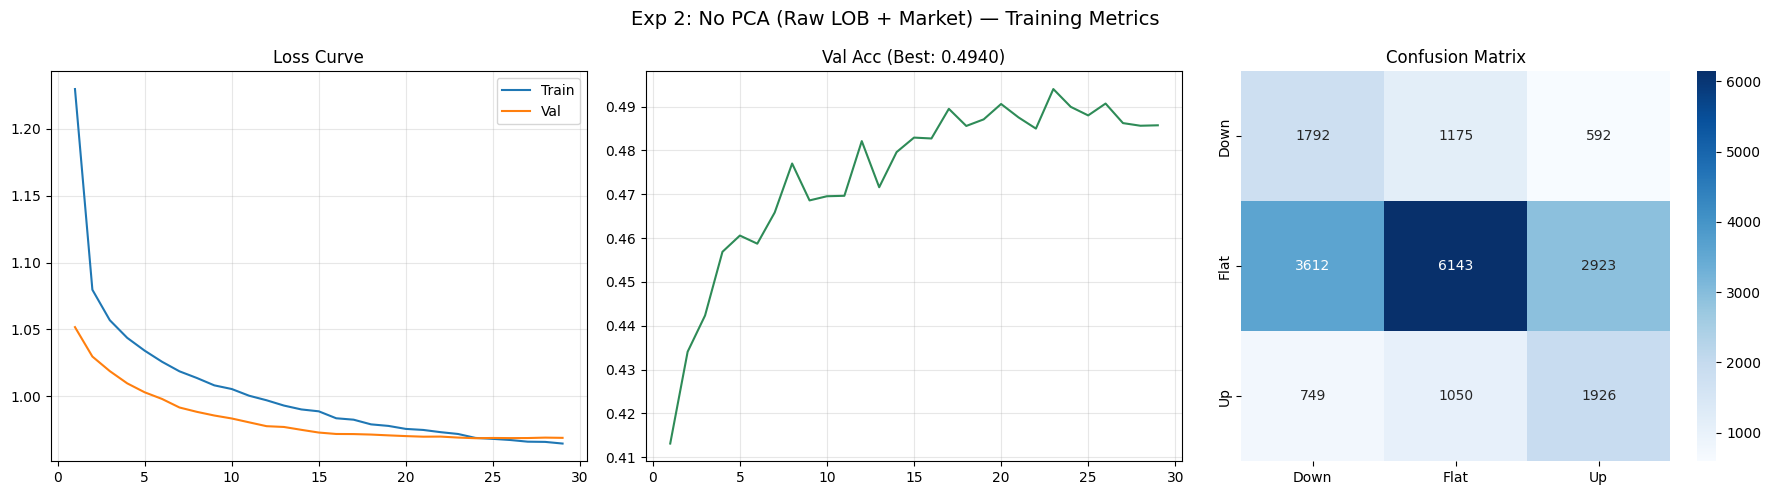


🚀 RUNNING EXPERIMENT: Exp 3: No Market (PCA LOB Only)
Features    : 30
Early stop at epoch 39. Best val acc: 0.3735

  Classification Report
              precision    recall  f1-score   support

        Down       0.27      0.63      0.37      3559
        Flat       0.75      0.24      0.37     12678
          Up       0.29      0.57      0.38      3725

    accuracy                           0.37     19962
   macro avg       0.43      0.48      0.37     19962
weighted avg       0.58      0.37      0.37     19962


---------------------------------------------
📊 BACKTEST RESULTS: Exp 3: No Market (PCA LOB Only) (Fee: 1.5 bps)
---------------------------------------------
Total Net Return : 66.58%
Annualized Sharpe: 543.68
Max Drawdown     : -3.36%
Win Rate         : 45.56%
Total Turnover   : 3,441 (Position Changes)


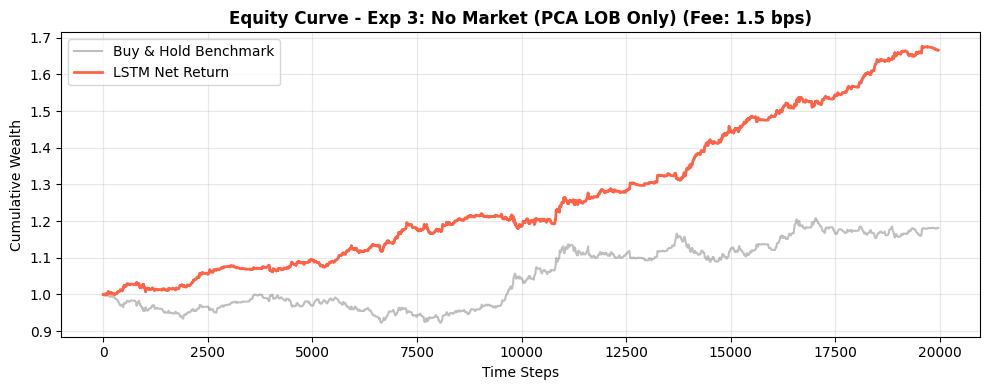

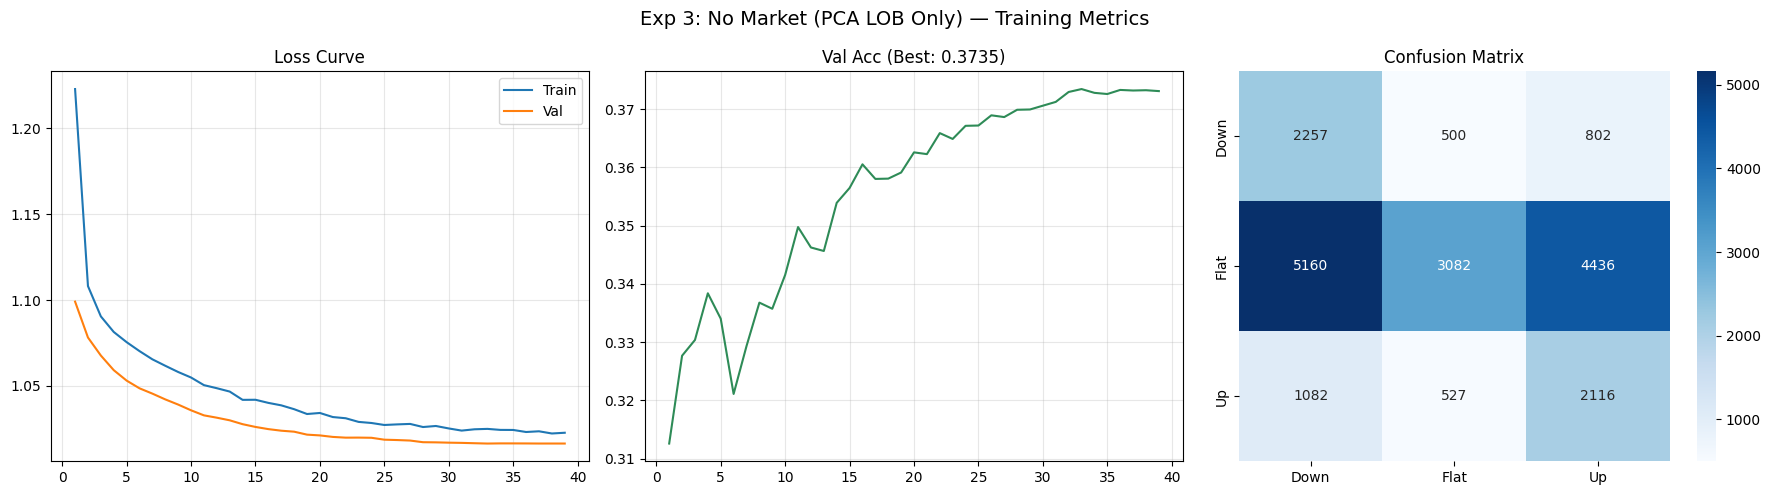



🏆 FINAL ABLATION STUDY RESULTS 🏆
| Experiment                       |   Features |   Best Acc |   Macro F1 | Net Return   |   Sharpe | Max DD   |
|:---------------------------------|-----------:|-----------:|-----------:|:-------------|---------:|:---------|
| Exp 1: Full (PCA LOB + Market)   |         45 |     0.4775 |     0.4328 | 44.09%       |   437.44 | -4.04%   |
| Exp 2: No PCA (Raw LOB + Market) |         75 |     0.494  |     0.4577 | 56.53%       |   527.49 | -2.78%   |
| Exp 3: No Market (PCA LOB Only)  |         30 |     0.3735 |     0.3745 | 66.58%       |   543.68 | -3.36%   |


In [12]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 挂载云盘
drive.mount('/content/drive')

# ==========================================
# 1. Hyperparameters & Settings
# ==========================================
SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 16
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 40
LR          = 1e-4
PATIENCE    = 6
EMBARGO_GAP = 10
FEE         = 0.00015 # 万分之五的单边手续费

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ==========================================
# 2. Dataset & Model Classes
# ==========================================
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]

class LOBLSTM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = N_LAYERS,
            batch_first   = True,
            bidirectional = True,
            dropout       = DROPOUT if N_LAYERS > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(HIDDEN_SIZE * 2)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name: nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name: nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        h = self.norm(h)
        return self.head(h)

# ==========================================
# 3. Backtest Engine (修正复利与换手，带资金曲线图)
# ==========================================
def simple_backtest(y_pred_labels, future_returns, fee=0.00015, exp_name="Strategy"):
    # 1. 将标签转为交易信号，计算换手率
    signals = y_pred_labels - 1
    trades = np.abs(np.diff(signals, prepend=0))
    transaction_costs = trades * fee

    # 2. 计算复利净收益
    net_returns = (signals * future_returns) - transaction_costs
    cum_returns = np.cumprod(1 + net_returns)
    market_cum = np.cumprod(1 + future_returns) # 大盘基准

    # 3. 计算核心指标
    total_return = cum_returns[-1] - 1
    annual_factor = 365 * 24 * 3600
    sharpe = np.mean(net_returns) / (np.std(net_returns) + 1e-8) * np.sqrt(annual_factor)

    running_max = np.maximum.accumulate(cum_returns)
    max_drawdown = np.min((cum_returns - running_max) / running_max)

    active_periods = (signals != 0).sum()
    win_rate = (net_returns > 0).sum() / (active_periods + 1e-8)

    # 4. 打印回测报告
    print("\n" + "-" * 45)
    print(f"📊 BACKTEST RESULTS: {exp_name} (Fee: {fee*10000:.1f} bps)")
    print("-" * 45)
    print(f"Total Net Return : {total_return:.2%}")
    print(f"Annualized Sharpe: {sharpe:.2f}")
    print(f"Max Drawdown     : {max_drawdown:.2%}")
    print(f"Win Rate         : {win_rate:.2%}")
    print(f"Total Turnover   : {trades.sum():,} (Position Changes)")

    # 5. 画出资金曲线图
    plt.figure(figsize=(10, 4))
    plt.plot(market_cum, label="Buy & Hold Benchmark", color="gray", alpha=0.5, linewidth=1.5)
    plt.plot(cum_returns, label="LSTM Net Return", color="tomato", linewidth=2)
    plt.title(f"Equity Curve - {exp_name} (Fee: {fee*10000:.1f} bps)", fontweight='bold')
    plt.ylabel("Cumulative Wealth")
    plt.xlabel("Time Steps")
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show() # 先展示资金曲线

    return total_return, sharpe, max_drawdown

# ==========================================
# 4. Experiment Encapsulation
# ==========================================
def run_experiment(file_name, exp_name):
    print("\n" + "=" * 80)
    print(f"🚀 RUNNING EXPERIMENT: {exp_name}")
    print("=" * 80)

    # 1. Load Data
    df = pd.read_csv(f"/content/drive/MyDrive/{file_name}")
    split_idx = int((df['split'] == 'train').sum())

    X_all = df.drop(columns=['label', 'split', 'future_return']).values.astype(np.float32)
    y_all = (df['label'].values + 1).astype(np.int64)
    returns_all = df['future_return'].values
    n_features = X_all.shape[1]

    print(f"Features    : {n_features}")

    # 2. Build Loaders
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_all[:split_idx])
    X_te   = scaler.transform(X_all[split_idx + EMBARGO_GAP :])
    y_tr, y_te = y_all[:split_idx], y_all[split_idx + EMBARGO_GAP :]

    test_returns = returns_all[split_idx + EMBARGO_GAP + SEQ_LEN - 1 :]

    y_tr_targets = y_tr[SEQ_LEN - 1:]
    counts  = np.bincount(y_tr_targets, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN), batch_size=BATCH_SIZE * 2, shuffle=False)

    # 3. Init Model
    model = LOBLSTM(n_features).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # 4. Training Loop
    best_acc, best_state, patience_cnt = 0.0, None, 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vloss += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total += len(yb)

        val_loss = vloss / total
        val_acc  = correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
                break

    # 5. Evaluate Best Model
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            preds = torch.argmax(model(Xb.to(DEVICE)), dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    val_f1 = f1_score(y_true, y_pred, average='macro')

    print("\n  Classification Report")
    print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

    # 6. Run Backtest (调用新版函数并传入 exp_name)
    ret, sharpe, max_dd = simple_backtest(y_pred, test_returns, fee=FEE, exp_name=exp_name)

    # 7. Plots (保持原有的训练指标三联图)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{exp_name} — Training Metrics", fontsize=14)
    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="Train")
    axes[0].plot(ep, history["val_loss"],   label="Val")
    axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history["val_acc"], color="seagreen")
    axes[1].set_title(f"Val Acc (Best: {best_acc:.4f})"); axes[1].grid(alpha=0.3)
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Down","Flat","Up"], yticklabels=["Down","Flat","Up"])
    axes[2].set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Experiment": exp_name,
        "Features": n_features,
        "Best Acc": round(best_acc, 4),
        "Macro F1": round(val_f1, 4),
        "Net Return": f"{ret:.2%}",
        "Sharpe": round(sharpe, 2),
        "Max DD": f"{max_dd:.2%}"
    }

# ==========================================
# 5. Execute Ablation Study
# ==========================================
experiments = [
    {"file": "lob_full.csv",      "name": "Exp 1: Full (PCA LOB + Market)"},
    {"file": "lob_no_pca.csv",    "name": "Exp 2: No PCA (Raw LOB + Market)"},
    {"file": "lob_no_market.csv", "name": "Exp 3: No Market (PCA LOB Only)"}
]

results = []
for exp in experiments:
    res = run_experiment(exp["file"], exp["name"])
    results.append(res)

# Print Final Ablation Table
print("\n\n" + "=" * 80)
print("🏆 FINAL ABLATION STUDY RESULTS 🏆")
print("=" * 80)
final_df = pd.DataFrame(results)
print(final_df.to_markdown(index=False))